In [120]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [121]:
df = pd.read_csv("../raw/netflix_titles.csv")


In [122]:
df.head(25)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [123]:
df.head(5).describe
df.shape
df.dtypes


show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [124]:
print(df['date_added'])

0        September 25, 2021
1        September 24, 2021
2        September 24, 2021
3        September 24, 2021
4        September 24, 2021
5        September 24, 2021
6        September 24, 2021
7        September 24, 2021
8        September 24, 2021
9        September 24, 2021
10       September 24, 2021
11       September 23, 2021
12       September 23, 2021
13       September 22, 2021
14       September 22, 2021
15       September 22, 2021
16       September 22, 2021
17       September 22, 2021
18       September 22, 2021
19       September 22, 2021
20       September 22, 2021
21       September 22, 2021
22       September 21, 2021
23       September 21, 2021
24       September 21, 2021
25       September 21, 2021
26       September 21, 2021
27       September 20, 2021
28       September 19, 2021
29       September 19, 2021
30       September 17, 2021
31       September 17, 2021
32       September 17, 2021
33       September 17, 2021
34       September 17, 2021
35       September 1

In [125]:
df['parsed_date'] = pd.to_datetime(df['date_added'], errors='coerce')

In [126]:
df['parsed_date'].head(5)

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: parsed_date, dtype: datetime64[ns]

In [127]:
from collections import Counter
Counter(','.join(df['listed_in'].dropna()).split(', '))

Counter({'International Movies': 838,
         'Dramas': 654,
         'Independent Movies': 424,
         'International TV Shows': 355,
         'International Movies,Dramas': 325,
         'International Movies,Comedies': 279,
         'Romantic TV Shows': 223,
         'Comedies': 200,
         'International Movies,Action & Adventure': 177,
         'International Movies,International TV Shows': 156,
         'TV Dramas': 133,
         'Romantic Movies,Dramas': 116,
         'International Movies,Documentaries': 112,
         'Korean TV Shows': 112,
         'Romantic Movies,Comedies': 109,
         'Docuseries': 91,
         'Thrillers,Dramas': 89,
         'TV Dramas,International TV Shows': 84,
         'TV Dramas,Dramas': 82,
         'TV Comedies': 80,
         'TV Action & Adventure': 78,
         'Music & Musicals,Dramas': 71,
         'Crime TV Shows': 68,
         'Thrillers,Comedies': 66,
         'TV Comedies,Dramas': 65,
         'International Movies,Crime TV Shows': 

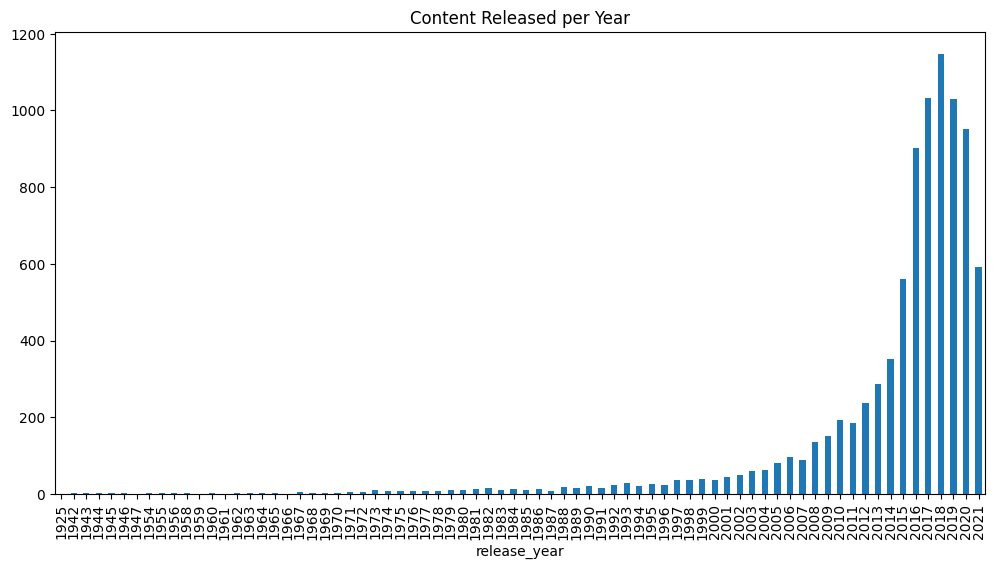

In [128]:
# Visualization: Count of Movies per year
plt.figure(figsize=(12,6))
df['release_year'].value_counts().sort_index().plot(kind='bar')
plt.title("Content Released per Year")
plt.show()

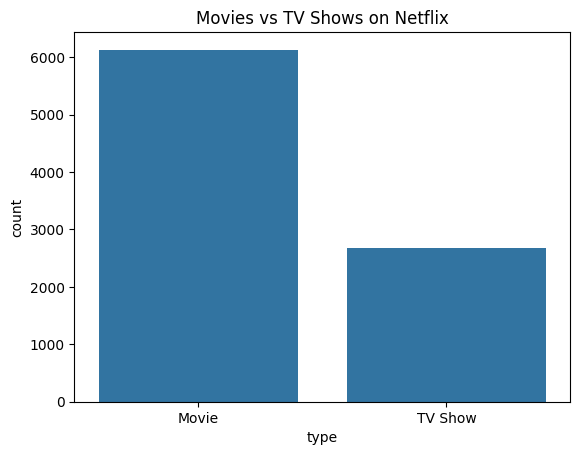

In [129]:
# Count movies vs TV shows
sns.countplot(data=df, x="type")
plt.title("Movies vs TV Shows on Netflix")
plt.show()

In [130]:
df.to_pickle("netflix_cleaned.pkl")
print("Saved cleaned dataframe!")

Saved cleaned dataframe!
